In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

In [3]:
df = pd.read_csv("../data/processed/raw_dataset.csv")
print(df.shape)
df.head()

(58062, 58)


,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,handles.nport,handles.nfile,handles.nevent,handles.ndesktop,handles.nkey,handles.nthread,handles.ndirectory,handles.nsemaphore,handles.ntimer,handles.nsection,handles.nmutant,ldrmodules.not_in_load,ldrmodules.not_in_init,ldrmodules.not_in_mem,ldrmodules.not_in_load_avg,ldrmodules.not_in_init_avg,ldrmodules.not_in_mem_avg,malfind.ninjections,malfind.commitCharge,malfind.protection,malfind.uniqueInjections,psxview.not_in_pslist,psxview.not_in_eprocess_pool,psxview.not_in_ethread_pool,psxview.not_in_pspcid_list,psxview.not_in_csrss_handles,psxview.not_in_session,psxview.not_in_deskthrd,psxview.not_in_pslist_false_avg,psxview.not_in_eprocess_pool_false_avg,psxview.not_in_ethread_pool_false_avg,psxview.not_in_pspcid_list_false_avg,psxview.not_in_csrss_handles_false_avg,psxview.not_in_session_false_avg,psxview.not_in_deskthrd_false_avg,modules.nmodules,svcscan.nservices,svcscan.kernel_drivers,svcscan.fs_drivers,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,Class,Category,Filename
0,45,17,10.555556,0,202.844444,1694,38.500000,9129,212.302326,0,670,3161,46,716,887,104,671,125,184,257,53,95,53,0.030372,0.054441,0.030372,5,21,30,1.250000,2,0,3,2,7,4,9,0.042553,0.0,0.063830,0.042553,0.148936,0.085106,0.191489,138,389,221,26,24,116,0,121,87,0,8,Benign,Benign,Benign
1,47,19,11.531915,0,242.234043,2074,44.127660,11385,242.234043,0,840,3761,51,1011,1030,117,766,148,337,394,77,123,77,0.036167,0.057774,0.036167,12,77,72,1.714286,0,0,0,0,4,2,6,0.000000,0.0,0.000000,0.000000,0.085106,0.042553,0.127660,138,392,222,26,24,118,0,122,87,0,8,Benign,Benign,Benign
2,40,14,14.725000,0,288.225000,1932,48.300000,11529,288.225000,0,1050,3996,45,784,1241,100,645,138,369,338,51,89,51,0.026114,0.045571,0.026114,5,6,30,1.250000,0,0,0,0,4,2,5,0.000000,0.0,0.000000,0.000000,0.100000,0.050000,0.125000,137,395,222,26,27,118,0,120,88,0,8,Benign,Benign,Benign
3,32,13,13.500000,0,264.281250,1445,45.156250,8457,264.281250,0,630,2961,36,654,792,83,567,127,186,242,31,62,31,0.021483,0.042966,0.021483,2,2,12,1.000000,0,0,0,0,4,2,6,0.000000,0.0,0.000000,0.000000,0.125000,0.062500,0.187500,138,395,222,26,27,118,0,120,88,0,8,Benign,Benign,Benign
4,42,16,11.452381,0,281.333333,2067,49.214286,11816,281.333333,0,908,3834,45,1252,942,103,825,135,375,429,102,143,102,0.047820,0.067042,0.047820,12,77,72,2.000000,4,0,4,4,8,6,10,0.086957,0.0,0.086957,0.086957,0.173913,0.130435,0.217391,138,392,222,26,24,118,0,124,87,0,8,Benign,Benign,Benign


In [4]:
ransomware_df = df[
    (df["Category"] == "Benign") |
    (df["Category"].str.startswith("Ransomware"))
].copy()

print(ransomware_df.shape)

(38760, 58)


In [5]:
ransomware_df["Target"] = (
    ransomware_df["Category"]
    .str.startswith("Ransomware")
    .astype(int)
)

In [6]:
ransomware_df["Target"].value_counts()

Target
0    29231
1     9529
Name: count, dtype: int64

In [7]:
print("Rows :", ransomware_df.shape[0])
print("Columns :", ransomware_df.shape[1])
print("\nClass Distribution")
print(ransomware_df["Target"].value_counts())

Rows : 38760
Columns : 59

Class Distribution
Target
0    29231
1     9529
Name: count, dtype: int64


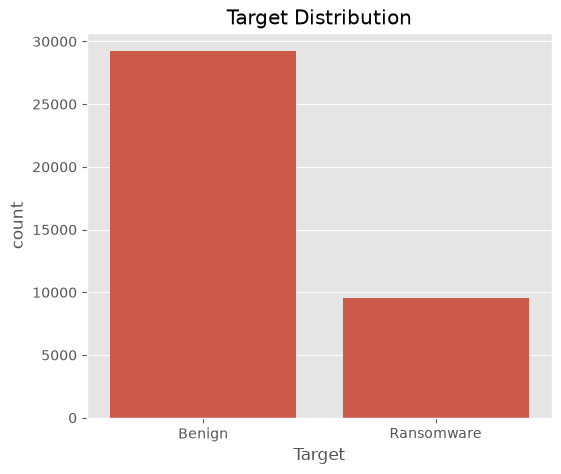

In [8]:
plt.figure(figsize=(6,5))
sns.countplot(
    data=ransomware_df,
    x="Target"
)
plt.xticks([0,1],["Benign","Ransomware"])
plt.title("Target Distribution")
plt.show()

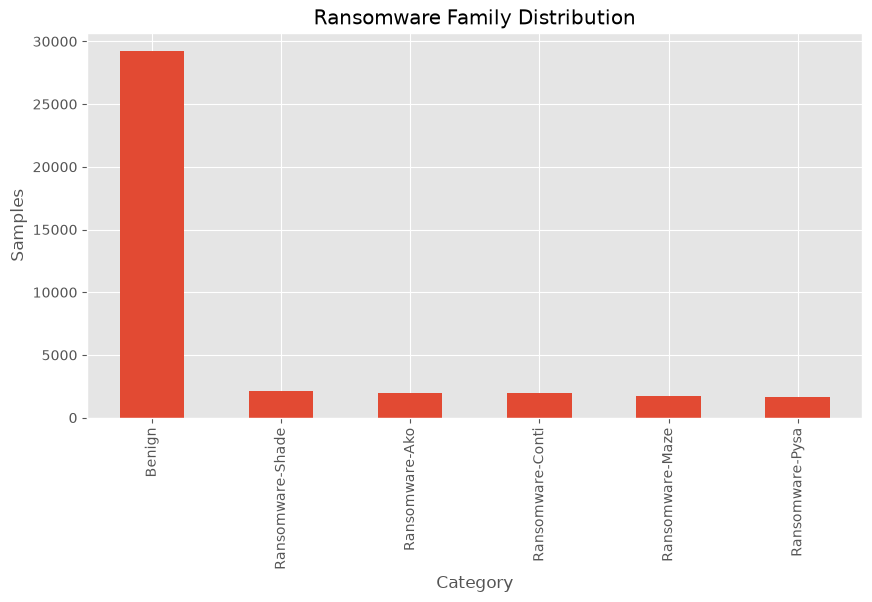

In [9]:
plt.figure(figsize=(10,5))
ransomware_df["Category"].value_counts().plot.bar()
plt.title("Ransomware Family Distribution")
plt.ylabel("Samples")
plt.show()

In [10]:
missing = ransomware_df.isnull().sum()
missing = missing[missing > 0]
missing

Series([], dtype: int64)

In [11]:
numerical = ransomware_df.select_dtypes(
    include=np.number
)
print(numerical.shape)

(38760, 56)


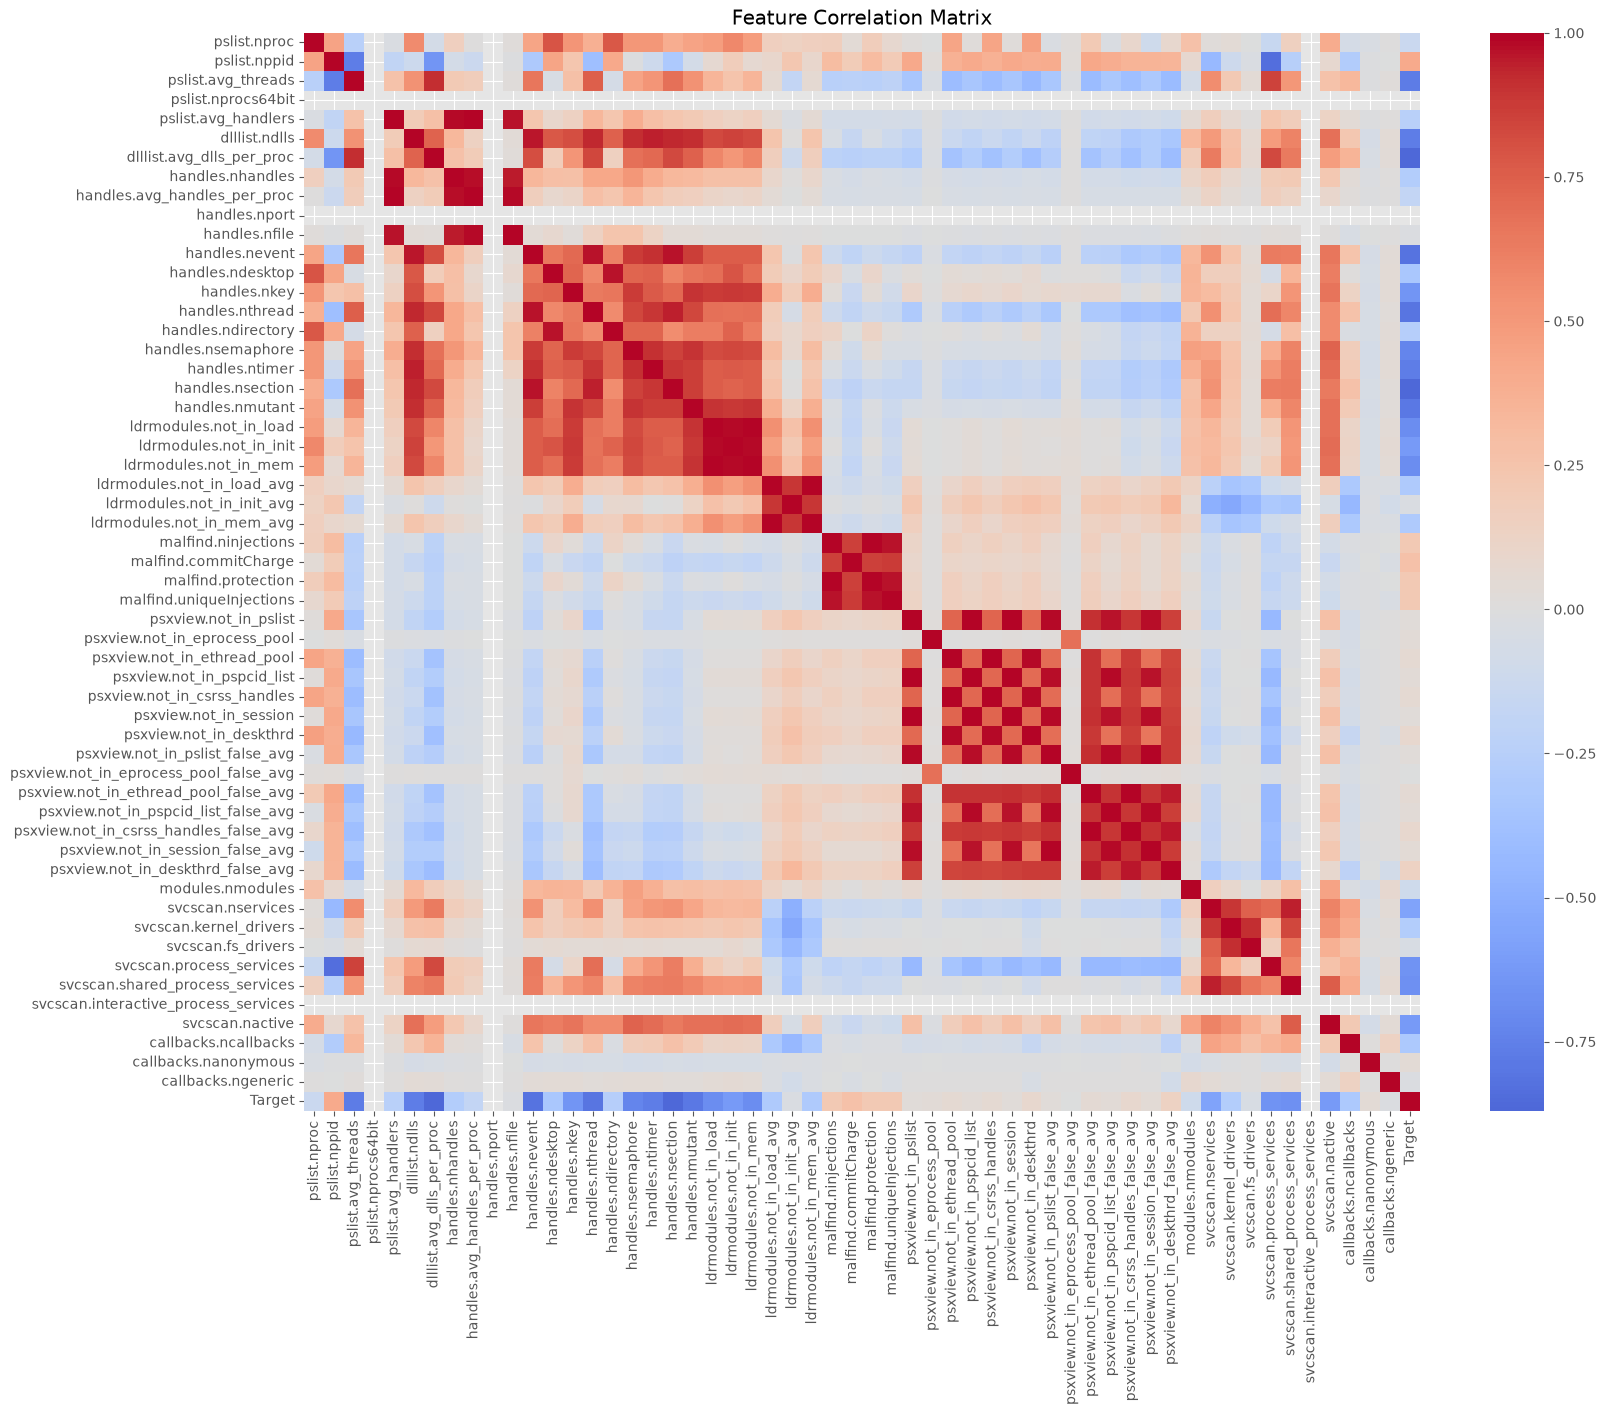

In [12]:
plt.figure(figsize=(18,14))
corr = numerical.corr()
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)
plt.title("Feature Correlation Matrix")
plt.show()

In [13]:
corr_matrix = numerical.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape),k=1).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]

print(high_corr)

['handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nfile', 'handles.nevent', 'handles.nthread', 'handles.ndirectory', 'handles.nsection', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_mem_avg', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_pspcid_list_false_avg', 'psxview.not_in_csrss_handles_false_avg', 'psxview.not_in_session_false_avg', 'psxview.not_in_deskthrd_false_avg']


In [14]:
variance = numerical.var()
variance.sort_values().head(20)

pslist.nprocs64bit                        0.000000
handles.nport                             0.000000
svcscan.interactive_process_services      0.000000
psxview.not_in_eprocess_pool_false_avg    0.000001
ldrmodules.not_in_load_avg                0.000081
ldrmodules.not_in_mem_avg                 0.000081
ldrmodules.not_in_init_avg                0.000103
callbacks.ngeneric                        0.000155
callbacks.nanonymous                      0.000773
psxview.not_in_eprocess_pool              0.001134
psxview.not_in_session_false_avg          0.003108
psxview.not_in_pslist_false_avg           0.003395
psxview.not_in_pspcid_list_false_avg      0.003493
psxview.not_in_csrss_handles_false_avg    0.003941
psxview.not_in_deskthrd_false_avg         0.003967
psxview.not_in_ethread_pool_false_avg     0.004656
modules.nmodules                          0.023615
svcscan.fs_drivers                        0.030478
Target                                    0.185411
svcscan.shared_process_services

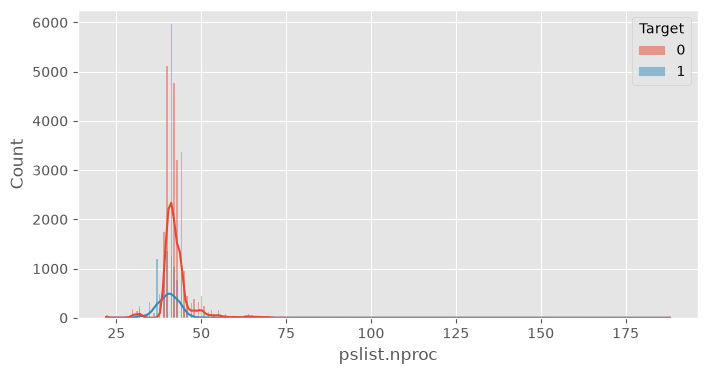

In [15]:
feature = numerical.columns[0]
plt.figure(figsize=(8,4))
sns.histplot(
    data=ransomware_df,
    x=feature,
    hue="Target",
    kde=True
)

plt.show()

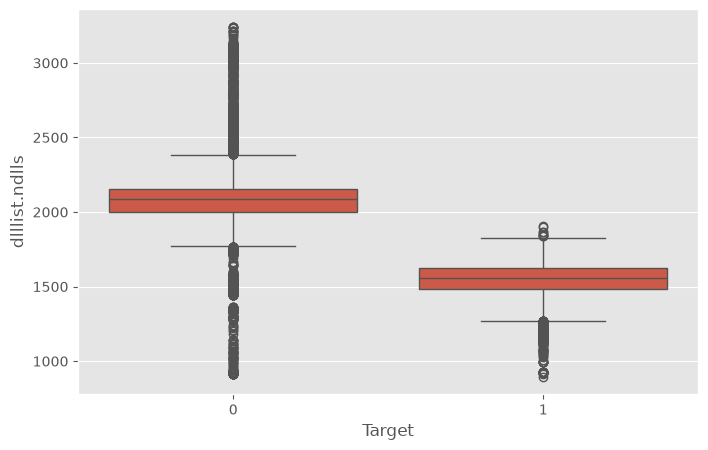

In [16]:
feature = numerical.columns[5]
plt.figure(figsize=(8,5))
sns.boxplot(
    data=ransomware_df,
    x="Target",
    y=feature
)
plt.show()

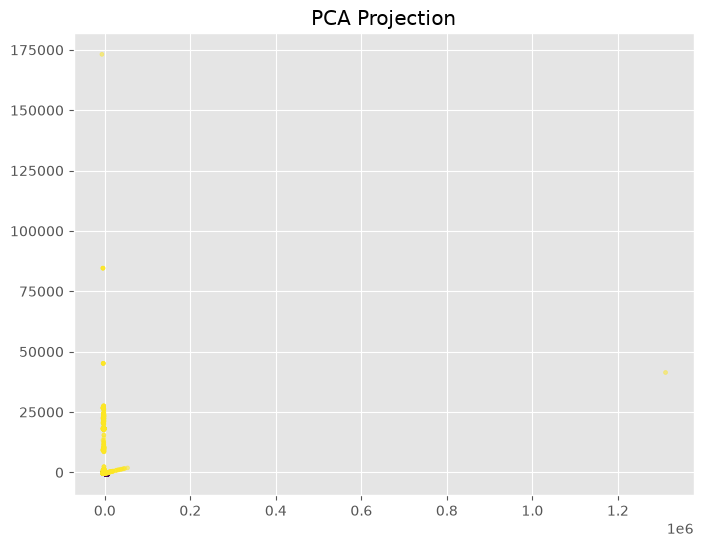

In [18]:
X = ransomware_df.drop(
    columns=["Filename","Category","Class","Target"]
)

y = ransomware_df["Target"]
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    s=8,
    alpha=0.5
)

plt.title("PCA Projection")

plt.show()

In [ ]:
sample = ransomware_df.sample(
    3000,
    random_state=42
)
X = sample.drop(
    columns=["Filename","Category","Class","Target"]
)
y = sample["Target"]

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\Asus-2025\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Users\Asus-2025\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Users\Asus-2025\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Users\Asus-2025\AppData\Roaming\uv\python\cpython-3.11-windows-x86_64-none\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x81 in position 73: character maps to <undefined>


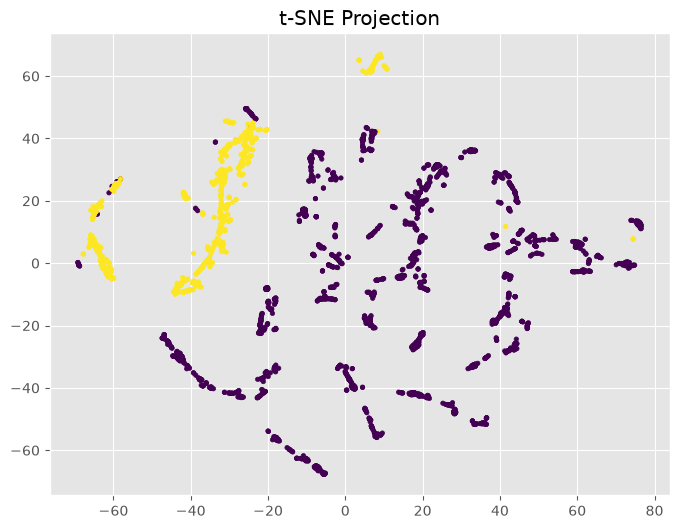

In [20]:
tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=y,
    s=10
)

plt.title("t-SNE Projection")

plt.show()

In [21]:
X = ransomware_df.drop(
    columns=["Filename","Category","Class","Target"]
)

y = ransomware_df["Target"]

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X,y)

importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf.feature_importances_

}).sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
6,dlllist.avg_dlls_per_proc,0.153777
45,svcscan.nservices,0.140569
46,svcscan.kernel_drivers,0.109973
4,pslist.avg_handlers,0.100754
49,svcscan.shared_process_services,0.077453
8,handles.avg_handles_per_proc,0.075589
18,handles.nsection,0.062313
11,handles.nevent,0.046532
19,handles.nmutant,0.035935
5,dlllist.ndlls,0.035165


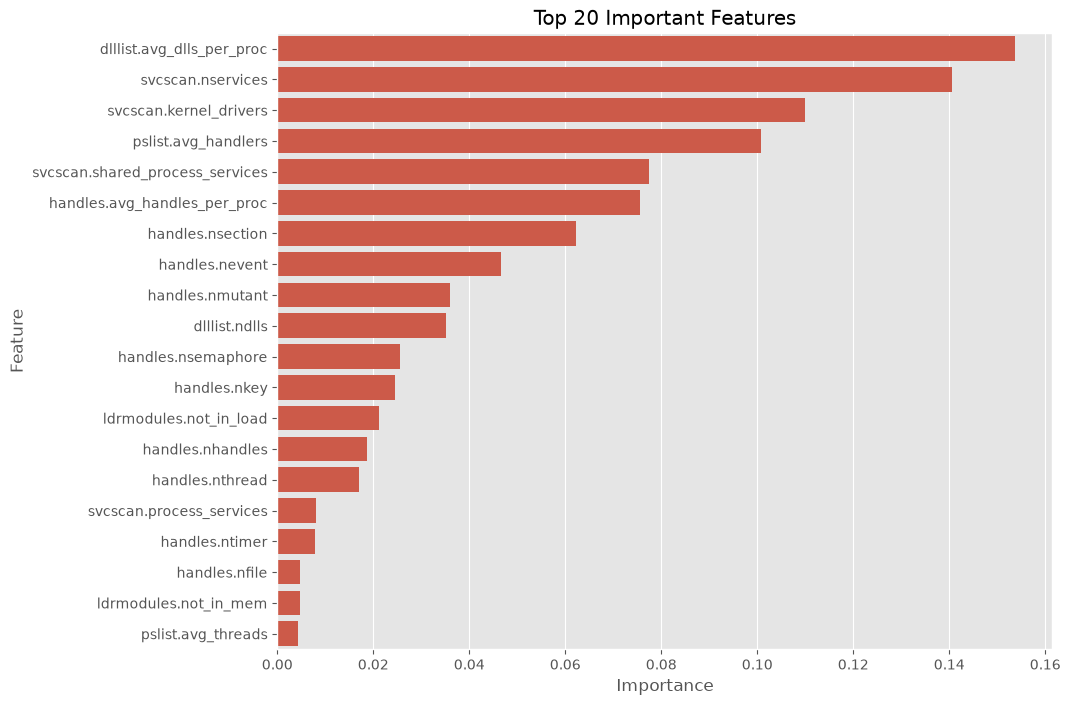

In [22]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Important Features")

plt.show()